kosis 물가상승률

In [56]:
import requests

url = "https://kosis.kr/openapi/Param/statisticsParameterData.do?method=getList&apiKey=UserKey=&itmId=T+&objL1=T10+&objL2=&objL3=&objL4=&objL5=&objL6=&objL7=&objL8=&format=json&jsonVD=Y&prdSe=Y&newEstPrdCnt=10&outputFields=PRD_DE+&orgId=101&tblId=DT_1J22003"
response = requests.get(url)
data = response.json()

type(data)

list

가져온 데이터 판다스 데이터프레임으로 변환

In [57]:
import pandas as pd

df_rate = pd.DataFrame(data)
df_rate

,DT,PRD_DE
0,94.861,2015
1,95.783,2016
2,97.645,2017
3,99.086,2018
4,99.466,2019
5,100,2020
6,102.5,2021
7,107.72,2022
8,111.59,2023
9,114.18,2024


최저임금 웹크롤링

In [58]:
import bs4
import urllib.request

nateUrl = "https://www.minimumwage.go.kr/minWage/policy/decisionMain.do"
htmlObject = urllib.request.urlopen(nateUrl)
webPage = htmlObject.read()
bsObject = bs4.BeautifulSoup(webPage, "html.parser")

table = bsObject.find('table')
rows = table.findAll('tr')

print(rows)

[<tr>
<th scope="col">적용연도</th>
<th scope="col">시간급</th>
<th scope="col">일급 <span>(8시간 기준)</span></th>
<th scope="col">월급 <span>(209시간 <br/>기준,고시기준)</span></th>
<th scope="col">인상률 <span>(인상액)</span></th>
<th scope="col">심의 <br/>의결일</th>
<th scope="col">결정 <br/>고시일</th>
</tr>, <tr>
<td>'26.01.01 <br/>~'26.12.31</td>
<td>10,320</td>
<td>82,560</td>
<td>2,156,880</td>
<td>2.9
                                        
                                            (290)
                                        
                                    </td>
<td>25.07.10</td>
<td>25.08.05</td>
</tr>, <tr>
<td>'25.01.01 <br/>~'25.12.31</td>
<td>10,030</td>
<td>80,240</td>
<td>2,096,270</td>
<td>1.7
                                        
                                            (170)
                                        
                                    </td>
<td>24.07.12</td>
<td>24.08.05</td>
</tr>, <tr>
<td>'24.01.01 <br/>~'24.12.31</td>
<td>9,860</td>
<td>78,880</td>
<td>2,060,740</td>


/tmp/ipython-input-2039443103.py:10: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  rows = table.findAll('tr')


가져온 열 정리 2025 ~ 2015

In [59]:
i=0
years = 2025
minimum_wage = {}
for row in rows[2:13]:
    columns = row.findAll('td')
    i+=1
    for column in columns:
        print(column.get_text())
    if i >= 1:

      money = columns[1].text
      print("money : ", money,"years : ",years)
      minimum_wage[years] = money
      print(minimum_wage)
      years -= 1

'25.01.01 ~'25.12.31
10,030
80,240
2,096,270
1.7
                                        
                                            (170)
                                        
                                    
24.07.12
24.08.05
money :  10,030 years :  2025
{2025: '10,030'}
'24.01.01 ~'24.12.31
9,860
78,880
2,060,740
2.5
                                        
                                            (240)
                                        
                                    
23.07.19
23.08.04
money :  9,860 years :  2024
{2025: '10,030', 2024: '9,860'}
'23.01.01 ~'23.12.31
9,620
76,960
2,010,580
5.0
                                        
                                            (460)
                                        
                                    
22.06.29
22.08.05
money :  9,620 years :  2023
{2025: '10,030', 2024: '9,860', 2023: '9,620'}
'22.01.01 ~'22.12.31
9,160
73,280
1,914,440
5.05
                                        
                    

/tmp/ipython-input-3446799446.py:5: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  columns = row.findAll('td')


값 확인 및 필요 없는 값 삭제

In [60]:
print(type(minimum_wage))
print(minimum_wage)
del minimum_wage[2025]
print(minimum_wage)


<class 'dict'>
{2025: '10,030', 2024: '9,860', 2023: '9,620', 2022: '9,160', 2021: '8,720', 2020: '8,590', 2019: '8,350', 2018: '7,530', 2017: '6,470', 2016: '6,030', 2015: '5,580'}
{2024: '9,860', 2023: '9,620', 2022: '9,160', 2021: '8,720', 2020: '8,590', 2019: '8,350', 2018: '7,530', 2017: '6,470', 2016: '6,030', 2015: '5,580'}


판다스 데이터에 맞게 역순으로 정렬

In [61]:
minimum_wage_sorted = dict(reversed(minimum_wage.items()))
print(minimum_wage_sorted)

{2015: '5,580', 2016: '6,030', 2017: '6,470', 2018: '7,530', 2019: '8,350', 2020: '8,590', 2021: '8,720', 2022: '9,160', 2023: '9,620', 2024: '9,860'}


판다스 데이터에 최저임금 삽입

In [62]:
df_rate['PRD_DE'] = df_rate['PRD_DE'].astype(int) # 타입 맞추기, 기존 타입은 str였음.
minimum_wage_num = {
    k: int(v.replace(',', '')) #key = k / value = int(v.replace(',',''))
    for k, v in minimum_wage_sorted.items()
}

df_rate['minimum_wage'] = df_rate['PRD_DE'].map(minimum_wage_num)
df_rate

,DT,PRD_DE,minimum_wage
0,94.861,2015,5580
1,95.783,2016,6030
2,97.645,2017,6470
3,99.086,2018,7530
4,99.466,2019,8350
5,100,2020,8590
6,102.5,2021,8720
7,107.72,2022,9160
8,111.59,2023,9620
9,114.18,2024,9860


데이터 전처리

순서, 컬럼 명 변경

In [63]:
df_rate.rename(columns={
    'DT':'inflation',
    'PRD_DE':'year'
}, inplace=True)
df_rate = df_rate[['year','minimum_wage', 'inflation']]
df_rate


,year,minimum_wage,inflation
0,2015,5580,94.861
1,2016,6030,95.783
2,2017,6470,97.645
3,2018,7530,99.086
4,2019,8350,99.466
5,2020,8590,100
6,2021,8720,102.5
7,2022,9160,107.72
8,2023,9620,111.59
9,2024,9860,114.18


데이터 타입 변경

In [64]:
df_rate.dtypes

,0
year,int64
minimum_wage,int64
inflation,object


In [65]:
df_rate['inflation'] = df_rate['inflation'].str.replace(',', '').astype(float)

In [66]:
df_rate.dtypes

,0
year,int64
minimum_wage,int64
inflation,float64


이상치 확인(minimum_wage)

In [67]:
q1_minimum = df_rate['minimum_wage'].quantile(0.25)
q2_minimum = df_rate['minimum_wage'].quantile(0.75)
print(q1_minimum, " : ",q2_minimum)
iqr_minimum = q2_minimum - q1_minimum
print(iqr_minimum)

upper_minimum = q2_minimum + (iqr_minimum * 1.5)
lower_minimum = q1_minimum - (iqr_minimum * 1.5)
print(upper_minimum, " : ",lower_minimum)

6735.0  :  9050.0
2315.0
12522.5  :  3262.5


이상치 확인(inflation)

In [68]:
q1_inflation = df_rate['inflation'].quantile(0.25)
q2_inflation = df_rate['inflation'].quantile(0.75)
print(f"{q1_inflation:.2f} : {q2_inflation:.2f}")
iqr_inflation = q2_inflation - q1_inflation
print(f"{iqr_inflation:.2f}")

upper_inflation = q2_inflation + (iqr_inflation * 1.5)
lower_inflation = q1_inflation - (iqr_inflation * 1.5)
print(f"{upper_inflation:.2f} : {lower_inflation:.2f}")

98.01 : 106.41
8.41
119.03 : 85.39


두 자료값의 상관관계 차이를 좁히기 위해 상승률 기준으로 잡기

기존 데이터로 새 데이터 프레임 생성

In [69]:
df_percent = df_rate[['year']].copy()

df_percent['wage_percent'] = df_rate['minimum_wage'].pct_change() * 100
df_percent['inflation_percent'] = df_rate['inflation'].pct_change() * 100
df_percent = df_percent.round(2)
df_percent

,year,wage_percent,inflation_percent
0,2015,NaN,NaN
1,2016,8.06,0.97
2,2017,7.30,1.94
3,2018,16.38,1.48
4,2019,10.89,0.38
5,2020,2.87,0.54
6,2021,1.51,2.50
7,2022,5.05,5.09
8,2023,5.02,3.59
9,2024,2.49,2.32


결측치 처리 (제거)

In [70]:
df_percent = df_percent.dropna()
df_percent

,year,wage_percent,inflation_percent
1,2016,8.06,0.97
2,2017,7.30,1.94
3,2018,16.38,1.48
4,2019,10.89,0.38
5,2020,2.87,0.54
6,2021,1.51,2.50
7,2022,5.05,5.09
8,2023,5.02,3.59
9,2024,2.49,2.32


상승률 기준으로 잡은 데이터 프레임의 그래프

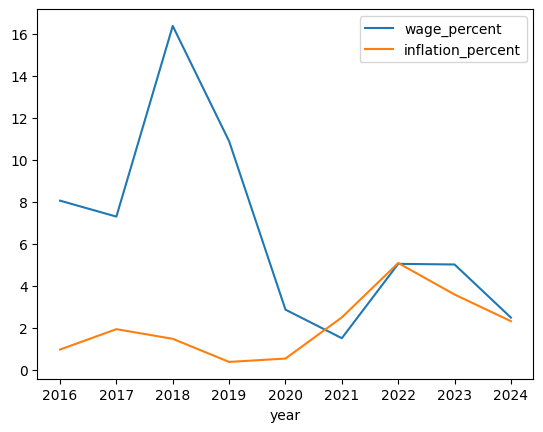

In [71]:
import matplotlib.pyplot as plt

df_percent.plot(x='year', y=['wage_percent', 'inflation_percent'])
plt.show()

상승률 데이터프레임 피어슨 상관분석

In [72]:
coef_p = df_percent.corr(method='pearson')
coef_p

,year,wage_percent,inflation_percent
year,1.00000,-0.591340,0.591850
wage_percent,-0.59134,1.000000,-0.336766
inflation_percent,0.59185,-0.336766,1.000000


상승률 데이터프레임 스피어만 상관분석

In [73]:
coef_s = df_percent.corr(method='spearman')
coef_s

,year,wage_percent,inflation_percent
year,1.000000,-0.683333,0.616667
wage_percent,-0.683333,1.000000,-0.466667
inflation_percent,0.616667,-0.466667,1.000000


상승률 데이터프레임 켄달 상관분석

In [74]:
coef_k = df_percent.corr(method='kendall')
coef_k

,year,wage_percent,inflation_percent
year,1.000000,-0.500000,0.388889
wage_percent,-0.500000,1.000000,-0.333333
inflation_percent,0.388889,-0.333333,1.000000


선형회귀분석

In [75]:
from sklearn.linear_model import LinearRegression

X = df_percent[['inflation_percent']]
y = df_percent['wage_percent']

model = LinearRegression()
model.fit(X, y)

기울기 = model.coef_[0]
절편 = model.intercept_
print(f"회귀식: 최저임금 상승률 = {기울기:.2f} x 물가 상승률 + {절편:.2f}")

회귀식: 최저임금 상승률 = -1.05 x 물가 상승률 + 8.81


물가 상승률이 3%일때 최저임금 상승률 예측

In [76]:
물가_상승률 = [[3]]
최저임금_상승률 = model.predict(물가_상승률)
print(f"물가 상승률이 3%일 때 최저임금 상승률은 {최저임금_상승률[0]:.2f}%입니다.")

물가 상승률이 3%일 때 최저임금 상승률은 5.67%입니다.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


성능 평가 시각화

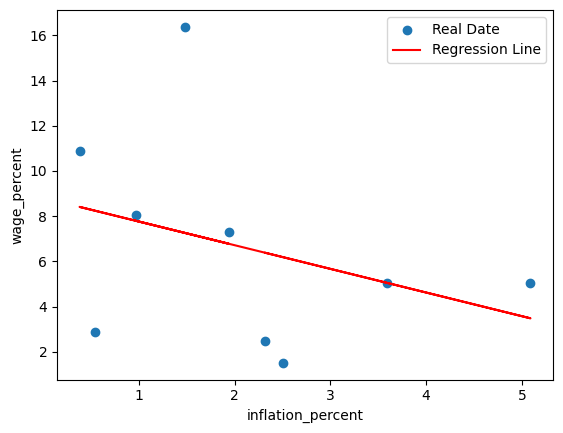

In [77]:
plt.scatter(X, y, label='Real Date')
plt.plot(X, model.predict(X), '-r', label='Regression Line')
plt.xlabel('inflation_percent')
plt.ylabel('wage_percent')
plt.legend()
plt.show()

결정계수, 분석결과

In [78]:
결정계수 = model.score(X, y)
print(f"결정계수: {결정계수:.2f}")

결정계수: 0.11


결과 : 물가 상승률 하나만으로 최저임금 상승률 변화 대부분을 알 수 없음.

독립변수에 연도 추가

In [79]:
X = df_percent[['inflation_percent','year']]
y = df_percent['wage_percent']

model = LinearRegression()
model.fit(X, y)

기울기 = model.coef_[0]
절편 = model.intercept_
print(f"회귀식: 최저임금 상승률 = {기울기:.2f} x 물가 상승률 + {절편:.2f}")

회귀식: 최저임금 상승률 = 0.06 x 물가 상승률 + 2107.47


2025년 물가 3% 상승시 최저임금 상승률 예측

In [80]:
물가_상승률 = [[2.83, 2025]]
최저임금_상승률 = model.predict(물가_상승률)
print(f"2025년에 물가 상승률이 3%일 때 최저임금 상승률은 {최저임금_상승률[0]:.2f}%입니다.")

2025년에 물가 상승률이 3%일 때 최저임금 상승률은 1.47%입니다.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


다중 회귀는 2D plot 불가능.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


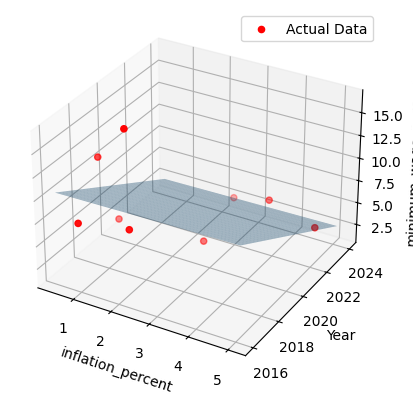

In [101]:
x_surf, y_surf = np.meshgrid(
    np.linspace(X['inflation_percent'].min(), X['inflation_percent'].max(), 50),
    np.linspace(X['year'].min(), X['year'].max(), 50)
)
z_surf = model.predict(np.column_stack([x_surf.ravel(), y_surf.ravel()])).reshape(x_surf.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X['inflation_percent'], X['year'], y, c='r', label='Actual Data')
ax.plot_surface(x_surf, y_surf, z_surf, alpha=0.4)

ax.set_xlabel("inflation_percent")
ax.set_ylabel("Year")
ax.set_zlabel("minimum_wage_percent")

plt.legend()
plt.show()

결정계수, 분석결과

In [81]:
결정계수 = model.score(X, y)
print(f"결정계수: {결정계수:.2f}")

결정계수: 0.35


결과 : 물가와 연도를 독립변수로 한 다음 회귀분석 결과 결정계수가 0.35로 상승하였음.

주성분 분석

In [82]:
import numpy as np
from sklearn.decomposition import PCA

inflation = df_percent['inflation_percent']
wage = df_percent['wage_percent']

percent_data = np.array([inflation,wage]).T
print(percent_data)

[[ 0.97  8.06]
 [ 1.94  7.3 ]
 [ 1.48 16.38]
 [ 0.38 10.89]
 [ 0.54  2.87]
 [ 2.5   1.51]
 [ 5.09  5.05]
 [ 3.59  5.02]
 [ 2.32  2.49]]


PCA 수행 및 데이터 변환

In [83]:
pca = PCA(n_components=2)
pca.fit(percent_data)
percent_data_pca = pca.transform(percent_data)

print("===변환된 데이터===")
print("제1주성분  제2주성분")
print(np.round(percent_data_pca,2))

===변환된 데이터===
제1주성분  제2주성분
[[ 1.56 -0.94]
 [ 0.69 -0.07]
 [ 9.76  0.55]
 [ 4.44 -1.19]
 [-3.54 -1.98]
 [-5.12 -0.2 ]
 [-1.91  2.79]
 [-1.77  1.3 ]
 [-4.13 -0.26]]


설명력 구하기

In [84]:
explained_data = pca.explained_variance_ratio_
print("===설명력===")
print(f"제1 주성분의 설명력: {explained_data[0]:.2f}")
print(f"제2 주성분의 설명력: {explained_data[1]:.2f}")

===설명력===
제1 주성분의 설명력: 0.92
제2 주성분의 설명력: 0.08


주성분을 이용한 선형회귀분석

In [85]:
X_pca = percent_data_pca[:,0].reshape(-1,1)
y = df_percent['wage_percent']

model.fit(X_pca, y)
기울기 = model.coef_[0]
절편 = model.intercept_
print(f"회귀식: 최저임금 상승률 = {기울기:.2f} x 제1주성분 + {절편:.2f}")

회귀식: 최저임금 상승률 = 0.99 x 제1주성분 + 6.62


물가 상승률과 최저임금 상승률 데이터를 대상으로 주성분 분석 시행 결과로, 제1주성분이 92%를 설명하고, 제2 주성분이 8%를 설명하였다.
대부분의 변화는 제1주성분으로, 제2주성분은 상대적으로 작은 변동을 설명함.


시계열 분석

In [86]:
from statsmodels.tsa.arima.model import ARIMA

df_wage = df_percent[['year','wage_percent']]
df_inflation = df_percent[['year','inflation_percent']]

df_wage.set_index('year', inplace=True)
df_inflation.set_index('year', inplace=True)

인덱스 연도 데이터 타입 변경. 정수 >> datetime

In [87]:
df_wage.index = pd.to_datetime(df_wage.index, format='%Y')
df_inflation.index = pd.to_datetime(df_inflation.index, format='%Y')

In [88]:
df_wage

,wage_percent
year,
2016-01-01,8.06
2017-01-01,7.30
2018-01-01,16.38
2019-01-01,10.89
2020-01-01,2.87
2021-01-01,1.51
2022-01-01,5.05
2023-01-01,5.02
2024-01-01,2.49


In [89]:
df_inflation

,inflation_percent
year,
2016-01-01,0.97
2017-01-01,1.94
2018-01-01,1.48
2019-01-01,0.38
2020-01-01,0.54
2021-01-01,2.50
2022-01-01,5.09
2023-01-01,3.59
2024-01-01,2.32


ARIMA 모델 만들고, 학습하기

In [90]:
model_wage = ARIMA(df_wage["wage_percent"], order=(1,1,1))
model_inflation = ARIMA(df_inflation["inflation_percent"], order=(1,1,1))

model_wage_fit = model_wage.fit()
model_inflation_fit = model_inflation.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be use

2025년 물가상승률 예측 및 시각화

In [91]:
inflation_forecast = model_inflation_fit.forecast(steps=1)
print(f"2025년 물가상승률 예측값: {inflation_forecast[0]:.2f}%")

2025년 물가상승률 예측값: 2.83%


/tmp/ipython-input-321813211.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"2025년 물가상승률 예측값: {inflation_forecast[0]:.2f}%")


/tmp/ipython-input-1064933166.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(df_inflation.index[-1] + pd.DateOffset(years=1), inflation_forecast[0], marker='o', label="Inflation Forecast", color='red')


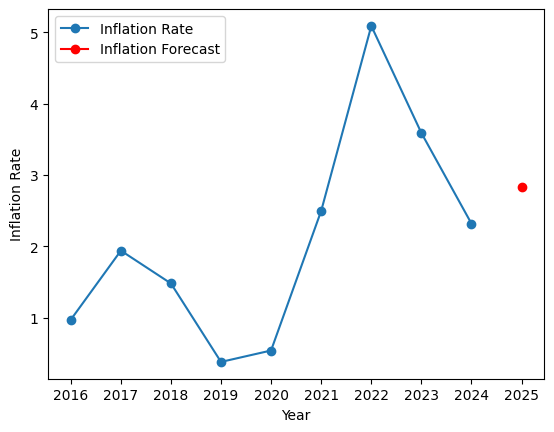

In [92]:
plt.plot(df_inflation.index, df_inflation["inflation_percent"], label="Inflation Rate", marker='o')
plt.plot(df_inflation.index[-1] + pd.DateOffset(years=1), inflation_forecast[0], marker='o', label="Inflation Forecast", color='red')
plt.xlabel("Year")
plt.ylabel("Inflation Rate")
plt.legend()
plt.show()

2025년 최저임금 상승률 예측 및 시각화

In [93]:
wage_forecast = model_wage_fit.forecast(steps=1)
print(f"2025년 최저임금 상승률 예측값: {wage_forecast[0]:.2f}%")

2025년 최저임금 상승률 예측값: 2.75%


/tmp/ipython-input-3067992555.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"2025년 최저임금 상승률 예측값: {wage_forecast[0]:.2f}%")


/tmp/ipython-input-94330884.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(df_wage.index[-1] + pd.DateOffset(years=1), wage_forecast[0], marker='o', label="Wage Forecast", color='red')


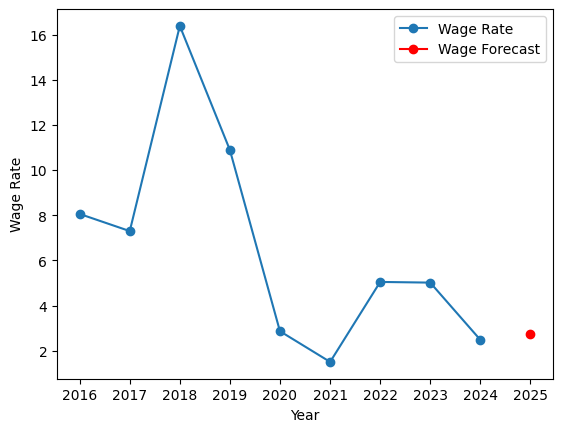

In [94]:
plt.plot(df_wage.index, df_wage["wage_percent"], label="Wage Rate", marker='o')
plt.plot(df_wage.index[-1] + pd.DateOffset(years=1), wage_forecast[0], marker='o', label="Wage Forecast", color='red')
plt.xlabel("Year")
plt.ylabel("Wage Rate")
plt.legend()
plt.show()

현재 최저임금과 예측 최저임금 비교 (ARIMA)

In [106]:
print("2024년 최저임금 : 9860 / 2025년 최저임금 : 10030")
pred_value = wage_forecast.iloc[0]

wage_comp = (pred_value / 100 + 1) * 9860
print(f"2025년 최저임금 예측 : {wage_comp:.2f}")

2024년 최저임금 : 9860 / 2025년 최저임금 : 10030
2025년 최저임금 예측 : 10130.81


In [107]:
from sklearn.linear_model import LinearRegression

X = df_percent[['inflation_percent']]
y = df_percent['wage_percent']

model = LinearRegression()
model.fit(X, y)

기울기 = model.coef_[0]
절편 = model.intercept_
print(f"회귀식: 최저임금 상승률 = {기울기:.2f} x 물가 상승률 + {절편:.2f}")

회귀식: 최저임금 상승률 = -1.05 x 물가 상승률 + 8.81


In [108]:
물가_상승률 = [[2.83]]
최저임금_상승률 = model.predict(물가_상승률)
print(f"물가 상승률이 3%일 때 최저임금 상승률은 {최저임금_상승률[0]:.2f}%입니다.")

물가 상승률이 3%일 때 최저임금 상승률은 5.84%입니다.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


선형회귀분석 결과와 ARIMA 결과 비교

In [111]:
print("2024년 최저임금 : 9860 / 2025년 최저임금 : 10030")

value_predict = 5.84
value_arima = 2.75 #pred_value = wage_forecast.iloc[0]

wage_comp_predict = (value_predict / 100 + 1) * 9860
wage_comp_arima = (value_arima / 100 + 1) * 9860

print(f"2025년 최저임금 예측(선형회귀분석) : {wage_comp_predict:.2f}")
print(f"2025년 최저임금 예측(ARIMA) : {wage_comp_arima:.2f}")

2024년 최저임금 : 9860 / 2025년 최저임금 : 10030
2025년 최저임금 예측(선형회귀분석) : 10435.82
2025년 최저임금 예측(ARIMA) : 10131.15
